## Failure Mode Classification

Path Setup

In [1]:
import os
import sys

project_root=os.path.abspath(os.path.join(os.getcwd(),'..'))
sys.path.append(project_root)

print(f"Project root: {project_root}")

Project root: c:\Users\aryap\Desktop\predictive_maintenance


In [ ]:
#!pip install imbalanced-learn


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ml imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics         import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing   import label_binarize
from imblearn.over_sampling  import SMOTE
import joblib

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

Load engineered data

In [6]:
data_path=os.path.join(project_root,'data','engineered_data.csv')
df=pd.read_csv(data_path)
print("Engineered data loaded")
print(f"Shape : {df.shape}")
print(f"Columns : {df.columns.tolist()}")

Engineered data loaded
Shape : (10000, 13)
Columns : ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'temp_diff', 'power', 'tool_wear_torque', 'type_encoded', 'rul', 'failure_mode_encoded', 'failure_mode', 'machine_failure']


Define features and target

In [8]:
feature_columns = [
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear',
    'temp_diff',
    'power',
    'tool_wear_torque',
    'type_encoded'
]

class_target = 'failure_mode_encoded'

# Class label mapping for display
class_names = {
    0: 'No Failure',
    1: 'HDF',
    2: 'OSF',
    3: 'PWF',
    4: 'TWF',
    5: 'RNF'
}

X = df[feature_columns]
y = df[class_target]

print("Features and target defined")
print(f" X shape : {X.shape}")
print(f" y shape : {y.shape}")
print(f"\n Class Distribution BEFORE SMOTE:")

for cls, name in class_names.items():
    count = (y == cls).sum()
    pct   = count / len(y) * 100
    print(f"   {cls} - {name:<15} : {count:>5} ({pct:.2f}%)")


Features and target defined
 X shape : (10000, 9)
 y shape : (10000,)

 Class Distribution BEFORE SMOTE:
   0 - No Failure      :  9652 (96.52%)
   1 - HDF             :   115 (1.15%)
   2 - OSF             :    92 (0.92%)
   3 - PWF             :    80 (0.80%)
   4 - TWF             :    43 (0.43%)
   5 - RNF             :    18 (0.18%)


train-test split before SMOTE

In [9]:
# CRITICAL: Split BEFORE applying SMOTE
# SMOTE must only be applied to training data
# Test set must remain original distribution
# Otherwise you're evaluating on synthetic data - invalid

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y   # ensures class proportions preserved in both splits
)

print(f"Stratified train/test split done")
print(f"  Train size : {X_train.shape[0]} rows")
print(f"  Test size  : {X_test.shape[0]} rows")

print(f" Class Distribution in Training Set (before SMOTE):")
for cls, name in class_names.items():
    count = (y_train == cls).sum()
    print(f"   {cls} — {name:<15} : {count:>5}")


Stratified train/test split done
  Train size : 8000 rows
  Test size  : 2000 rows
 Class Distribution in Training Set (before SMOTE):
   0 — No Failure      :  7722
   1 — HDF             :    92
   2 — OSF             :    74
   3 — PWF             :    64
   4 — TWF             :    34
   5 — RNF             :    14


Apply SMOTE to training data only

In [10]:
#SMOTE- Synthetic Minority Oversampling
# creates synthetic samples for minority classes by interpolating between existing minority samples

smote=SMOTE(
    random_state=42,
    k_neighbors=5 # uses 5 nearest neighbors to generate synthetic samples
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"SMOTE applied to training data")
print(f"\nClass Distribution AFTER SMOTE:")
for cls, name in class_names.items():
    before = (y_train == cls).sum()
    after  = (y_train_smote == cls).sum()
    added  = after - before
    print(f"   {cls} — {name:<15} : {before:>5} → {after:>5}  (+{added})")
print(f"\n   Training set size before SMOTE : {X_train.shape[0]}")
print(f"   Training set size after  SMOTE : {X_train_smote.shape[0]}")
print(f"\n   Test set unchanged             : {X_test.shape[0]} rows")

SMOTE applied to training data

Class Distribution AFTER SMOTE:
   0 — No Failure      :  7722 →  7722  (+0)
   1 — HDF             :    92 →  7722  (+7630)
   2 — OSF             :    74 →  7722  (+7648)
   3 — PWF             :    64 →  7722  (+7658)
   4 — TWF             :    34 →  7722  (+7688)
   5 — RNF             :    14 →  7722  (+7708)

   Training set size before SMOTE : 8000
   Training set size after  SMOTE : 46332

   Test set unchanged             : 2000 rows


Visualization :class balance before and after SMOTE

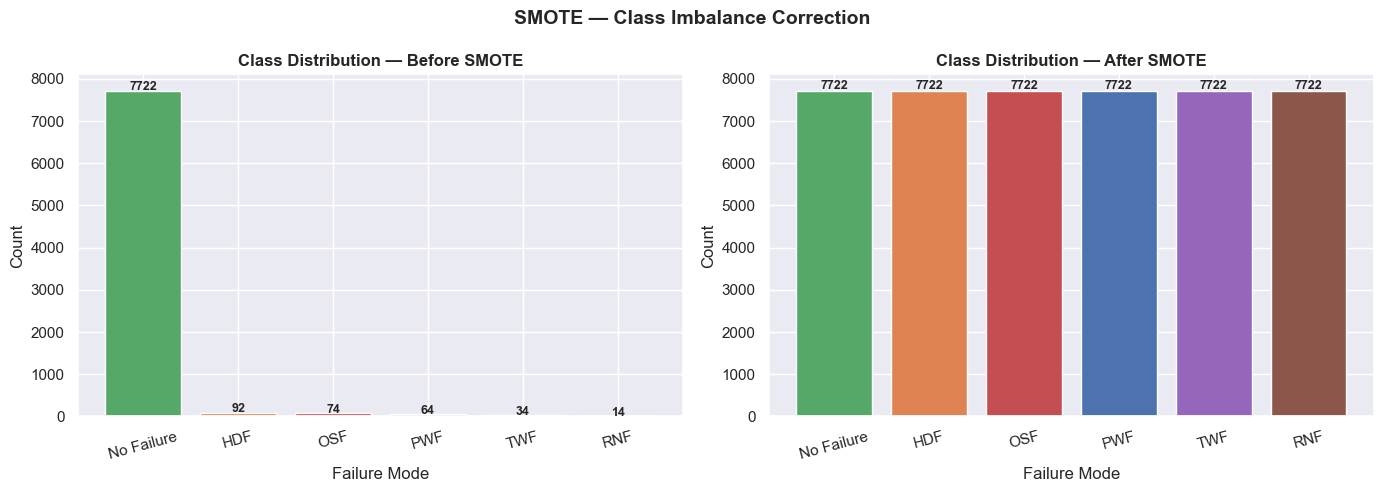

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_labels = [class_names[i] for i in sorted(class_names.keys())]

# ── Before SMOTE ──
before_counts = [( y_train == cls).sum() for cls in sorted(class_names.keys())]
colors        = ['#55A868', '#DD8452', '#C44E52', '#4C72B0', '#9467BD', '#8C564B']

bars1 = axes[0].bar(class_labels, before_counts, color=colors, edgecolor='white')
for bar, count in zip(bars1, before_counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count), ha='center', fontsize=9, fontweight='bold'
    )
axes[0].set_title('Class Distribution — Before SMOTE',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Failure Mode')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# ── After SMOTE ──
after_counts = [(y_train_smote == cls).sum() for cls in sorted(class_names.keys())]

bars2 = axes[1].bar(class_labels, after_counts, color=colors, edgecolor='white')
for bar, count in zip(bars2, after_counts):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        str(count), ha='center', fontsize=9, fontweight='bold'
    )
axes[1].set_title('Class Distribution — After SMOTE',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Failure Mode')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('SMOTE — Class Imbalance Correction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/smote_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


Training Random Forest Classifier

In [13]:
# Train random forest classifier on SMOTE-balanced training data

rf_classifier=RandomForestClassifier(
    n_estimators=100,
    max_depth=None, #trees grow fully
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train_smote,y_train_smote)
y_pred_class=rf_classifier.predict(X_test)
y_pred_proba=rf_classifier.predict_proba(X_test)

print("Random forest classifier trained")
print(f"Training samples (after SMOTE) : {X_train_smote.shape[0]}")
print(f"Test samples:{X_test.shape[0]}")
print(f"Classes predicted:{rf_classifier.classes_}")

Random forest classifier trained
Training samples (after SMOTE) : 46332
Test samples:2000
Classes predicted:[0 1 2 3 4 5]


Classification report

In [15]:
print("Classification Report")


report = classification_report(
    y_test,
    y_pred_class,
    target_names = [class_names[i] for i in sorted(class_names.keys())],
    digits       = 4
)
print(report)

# Overall F1 scores
macro_f1    = f1_score(y_test, y_pred_class, average='macro')
weighted_f1 = f1_score(y_test, y_pred_class, average='weighted')

print(f"Macro F1    : {macro_f1:.4f}")
print(f"Weighted F1 : {weighted_f1:.4f}")

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9937    0.9798    0.9867      1930
         HDF     0.9200    1.0000    0.9583        23
         OSF     0.7826    1.0000    0.8780        18
         PWF     1.0000    1.0000    1.0000        16
         TWF     0.0714    0.1111    0.0870         9
         RNF     0.0000    0.0000    0.0000         4

    accuracy                         0.9745      2000
   macro avg     0.6280    0.6818    0.6517      2000
weighted avg     0.9849    0.9745    0.9795      2000

Macro F1    : 0.6517
Weighted F1 : 0.9795


Confusion matrix

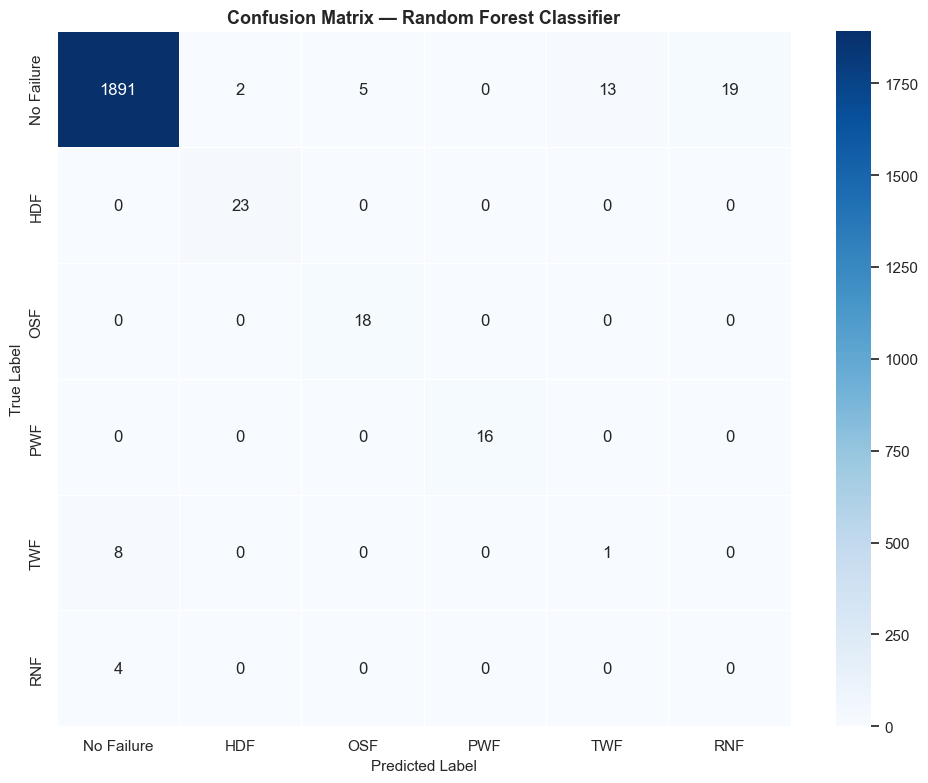

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

cm           = confusion_matrix(y_test, y_pred_class)
class_labels = [class_names[i] for i in sorted(class_names.keys())]

sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= class_labels,
    yticklabels= class_labels,
    linewidths = 0.5,
    ax         = ax
)

ax.set_title('Confusion Matrix — Random Forest Classifier',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Per class F1 bar chart

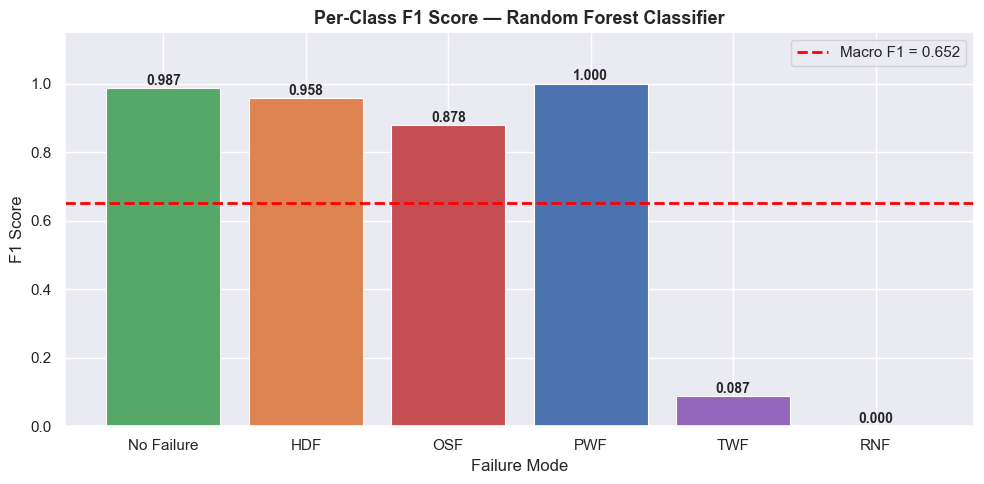

In [19]:
report_dict  = classification_report(
    y_test,
    y_pred_class,
    target_names = class_labels,
    output_dict  = True
)

per_class_f1 = {
    name: report_dict[name]['f1-score']
    for name in class_labels
}

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#55A868', '#DD8452', '#C44E52', '#4C72B0', '#9467BD', '#8C564B']
bars   = ax.bar(
    per_class_f1.keys(),
    per_class_f1.values(),
    color     = colors,
    edgecolor = 'white',
    linewidth = 0.8
)

for bar, val in zip(bars, per_class_f1.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center', fontsize=10, fontweight='bold'
    )

ax.axhline(y=macro_f1, color='red', linestyle='--',
           linewidth=2, label=f'Macro F1 = {macro_f1:.3f}')
ax.set_title('Per-Class F1 Score — Random Forest Classifier',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Failure Mode')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()


AUC-ROC (one vs rest)

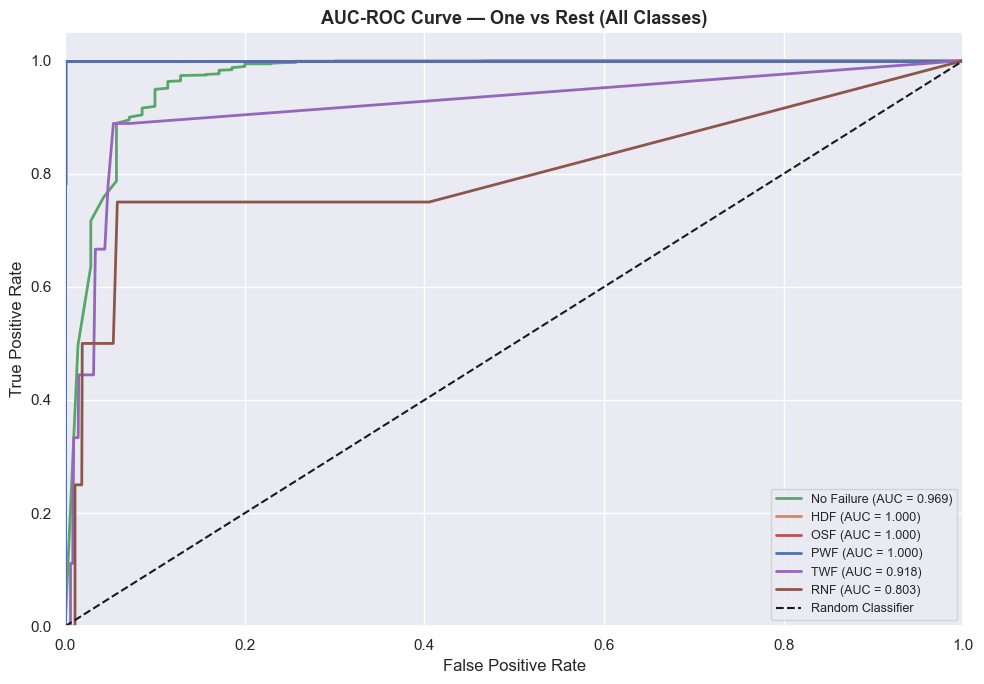


AUC-ROC Scores per Class:
   No Failure      : 0.9688
   HDF             : 0.9998
   OSF             : 1.0000
   PWF             : 1.0000
   TWF             : 0.9182
   RNF             : 0.8029
   Mean AUC     : 0.9483


In [20]:
# Binarize test labels for one-vs-rest ROC
n_classes  = len(class_names)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(10, 7))

colors_roc = ['#55A868', '#DD8452', '#C44E52', '#4C72B0', '#9467BD', '#8C564B']
auc_scores = {}

for i, (cls, name) in enumerate(class_names.items()):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[name] = roc_auc

    ax.plot(fpr, tpr,
            color     = colors_roc[i],
            linewidth = 2,
            label     = f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.set_title('AUC-ROC Curve — One vs Rest (All Classes)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('../notebooks/auc_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAUC-ROC Scores per Class:")

for name, score in auc_scores.items():
    print(f"   {name:<15} : {score:.4f}")

print(f"   Mean AUC     : {np.mean(list(auc_scores.values())):.4f}")

save classifier model

In [21]:
classifier_path = os.path.join(project_root, 'models', 'rf_classifier.pkl')

joblib.dump(rf_classifier, classifier_path)

print(f"Random Forest Classifier saved")
print(f"   Path : {classifier_path}")
print(f"   Size : {os.path.getsize(classifier_path) / 1024:.1f} KB")

Random Forest Classifier saved
   Path : c:\Users\aryap\Desktop\predictive_maintenance\models\rf_classifier.pkl
   Size : 12240.1 KB
